# Rich Neale's Blocking Diagnostic (ESNB version)
More details on the development process:
[MDTF Planning Document](https://docs.google.com/document/d/1P8HqL8O5304qwR3ik9RmgFDwSWwlkPgOjnp39PIkLfY/edit?usp=sharing)

[ESNB GitHub Repository](https://github.com/jkrasting/esnb/tree/ncar-updates)

In [1]:
# Development mode: constantly refreshes module code
%load_ext autoreload
%autoreload 2


In [2]:
# IMPORT General PACKAGES

import importlib

import sys
import yaml
import json

import os


In [3]:

# Use dask jobqueue
from dask_jobqueue import PBSCluster

# Import a client
from dask.distributed import Client

#P03010039. #P93300642

#client = Client()  # try connecting to any existing cluster
#client


cluster = PBSCluster(cores=4, memory="8GB", account='P03010039', interface='ext', job_extra_directives=[], walltime='2:00:00', queue='casper', resource_spec='select=1:ncpus=4:mem=8GB')
cluster
cluster.scale(jobs=1)
client = Client(cluster)
client


/glade/u/apps/opt/conda/envs/npl/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 37451 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: http://128.117.211.221:37451/status,
Dashboard: http://128.117.211.221:37451/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.211.221:38175,Workers: 0
Dashboard: http://128.117.211.221:37451/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [4]:
# Runtime settings (unrelated to the specific diagnostic or the model data)
#%%time

# Define a mode (interactive or prod = production (batch))
mode = "interactive"

# Verbosity
verbose = True

# Give your diagnostic a name and a short description
diag_name = "Blocking (Neale) Notebook-based Diagnostic"
diag_desc = "This example demonstrates how to use the notebook template"


In [5]:
#
# More settings, maybe get rid of some #DRBDBG 
# 

mode = "interactive"
# mode:
#        interactive = running this as a notebook, input is provided through the notebook interface
#        driver      = MDTF called from the command line, input provided through command line arguments (-f file.yaml)

usage = "dev"
# usage:
#         dev  (development): either CESM time series files with no pre-processing done
#                             OR pre-processed files already made, used directly
#         prod (production) : MDTF full functionality. 
#                             Any supported data type is provided through catalogs and translated as necessary
#                             by the MDTF pre-processor.
#       

machine = "casper-env-not-set"
# machine:
#         Uses machine-specfic things such as dask. 
#         This should be determined by the framework
#         And needs implementation for conda envs. 

test = 0 
# test: 
#         test = 1: find and load data, skip analysis/plotting
#         test = 0: run the full analysis and plottings
#



## Framework Code and Diagnostic Setup

In [6]:
# 
# Framework: Setup paths to use MDTF code
#
module_path = os.path.abspath(os.path.join('../../'))  #one above src
print(f"Using MDTF framework version {module_path}")
if module_path not in sys.path:
    sys.path.append(module_path)
from src import util              #, varlist_util, translation, xr_parser, units
from src.util import json_utils

import blocking_utils as block_utils
import blocking_figs as block_figs


Using MDTF framework version /glade/u/home/bundy/mdtf/MDTF_current/MDTF-diagnostics.blocking_notebook


In [7]:
# The ESNB package has  notebook-specific classes and functions
import esnb
from esnb import NotebookDiagnostic, RequestedVariable, CaseGroup2

os.environ["ESNB_LOG_LEVEL"] = "DEBUG"

In [8]:
#### POD settings are defined here (interactive mode) or read
#### from the diagnostics/blocking_notebook/settings.jsonc file  

if (mode == "interactive"):
  settings_dict = {
    "settings": {

        # ---------------------------------------------------
        #The pod_env_vars are used in the POD, not required by the MDTF framework
        # ---------------------------------------------------
        "pod_env_vars": {  
            "MDTF_BLOCKING_OBS": True,
            "MDTF_BLOCKING_OBS_USE_CASE_YEARS": False,
            "MDTF_BLOCKING_OBS_ERA_FIRSTYR": 2010,
            "MDTF_BLOCKING_OBS_ERA_LASTYR": 2014,
            "MDTF_BLOCKING_OBS_MERRA_FIRSTYR": 2009,
            "MDTF_BLOCKING_OBS_MERRA_LASTYR": 2011,
            "MDTF_BLOCKING_OBS_CAM5_FIRSTYR": 1979,
            "MDTF_BLOCKING_OBS_CAM5_LASTYR": 2007,
            "MDTF_BLOCKING_CAM3": False,
            "MDTF_BLOCKING_CAM4": False,
            "MDTF_BLOCKING_CAM5": True,
            "MDTF_BLOCKING_READ_DIGESTED": True,
            "MDTF_BLOCKING_WRITE_DIGESTED": False,
            "MDTF_BLOCKING_WRITE_DIGESTED_DIR": "",
            "MDTF_BLOCKING_DEBUG": False
        },
        
        # ---------------------------------------------------
        # The following settings are used by the MDTF framework
        # ---------------------------------------------------
        "runtime_requirements": {
            "python3": None,  # None means use the default python version of the MDTF framework
        },
        "driver": "blocking_main.ipynb",
        "long_name": "Rich Neale's blocking diagnostic",
        "convention": "cesm",
        "description": "Rich Neale's blocking diagnostic", 
    },
    "dimensions": {
        "lat": {
            "standard_name": "latitude",
            "units": "degrees_north",
            "axis": "Y"
        },
        "lon": {
            "standard_name": "longitude",
            "units": "degrees_east",
            "axis": "X"
        },
        "lev": {
            "standard_name": "air_pressure",
            "units": "hPa",
            "positive": "down",
            "axis": "Z"
        },
        "time": {
            "standard_name": "time"
        }
    },
    "varlist": {
        "zg": {
            "path_variable": "MODEL_DATA_PATH",  
            "standard_name": "geopotential_height",
            "units": "m",
            "realm": "atmos",
            "frequency": "day",
            "dimensions": [
                "time",
                "lat",
                "lon"
            ],
            "scalar_coordinates": {
                "lev": 500
            }
        }
    }
}
else:  # batch mode: running from the command line, read in the settings file
    import json

    # Specify the path to the JSONC file
    settings_file_path = "./settings.jsonc"

    try:
        # Open and read the JSONC file using MDTF framework's json_utils
        settings = json_utils.read_json(settings_file_path)
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

# Pretty-print the loaded JSON data
print(json_utils.pretty_print_json(settings_dict))
    



  settings: 
    pod_env_vars: 
      MDTF_BLOCKING_OBS: true
      MDTF_BLOCKING_OBS_USE_CASE_YEARS: false
      MDTF_BLOCKING_OBS_ERA_FIRSTYR: 2010
      MDTF_BLOCKING_OBS_ERA_LASTYR: 2014
      MDTF_BLOCKING_OBS_MERRA_FIRSTYR: 2009
      MDTF_BLOCKING_OBS_MERRA_LASTYR: 2011
      MDTF_BLOCKING_OBS_CAM5_FIRSTYR: 1979
      MDTF_BLOCKING_OBS_CAM5_LASTYR: 2007
      MDTF_BLOCKING_CAM3: false
      MDTF_BLOCKING_CAM4: false
      MDTF_BLOCKING_CAM5: true
      MDTF_BLOCKING_READ_DIGESTED: true
      MDTF_BLOCKING_WRITE_DIGESTED: false
      MDTF_BLOCKING_WRITE_DIGESTED_DIR: ""
      MDTF_BLOCKING_DEBUG: false
    runtime_requirements: 
      python3: null
    driver: blocking_main.ipynb
    long_name: Rich Neale's blocking diagnostic
    convention: cesm
    description: Rich Neale's blocking diagnostic
  dimensions: 
    lat: 
      standard_name: latitude
      units: degrees_north
      axis: Y
    lon: 
      standard_name: longitude
      units: degrees_east
      axis: X
    lev: 

In [9]:
# We should ask developers to generate a settings file before submitting. But while developing, it is easier to use the settings_dict directly.

#  Initialize the diagnostic with its name, description, vars, and options
# This is the setttings file from mdtf/diagnostics/$DIAG_NAME/settings.jsonc (Must be full path)
#test diag = NotebookDiagnostic("/glade/u/home/bundy/diag/mdtf/esnb/esnb/src/esnb/data/settings.jsonc")
diag = NotebookDiagnostic(settings_dict)
#print(diag)
from pprint import pprint
pprint(vars(diag))

{'_observers': {},
 '_settings_keys': ['runtime_requirements',
                    'long_name',
                    'driver',
                    'description',
                    'pod_env_vars',
                    'convention'],
 'convention': 'cesm',
 'description': "Rich Neale's blocking diagnostic",
 'diag_vars': {},
 'dimensions': {'lat': {'axis': 'Y',
                        'standard_name': 'latitude',
                        'units': 'degrees_north'},
                'lev': {'axis': 'Z',
                        'positive': 'down',
                        'standard_name': 'air_pressure',
                        'units': 'hPa'},
                'lon': {'axis': 'X',
                        'standard_name': 'longitude',
                        'units': 'degrees_east'},
                'time': {'standard_name': 'time'}},
 'driver': 'blocking_main.ipynb',
 'groups': [],
 'long_name': "Rich Neale's blocking diagnostic",
 'name': "Rich Neale's blocking diagnostic",
 'pod_env_vars': {

In [10]:
#This information should be deduced from the mdtf/data/fieldlist_$MODEL.json files
mapping = {
    "zg": "Z500",
}


In [11]:

if (mode == "interactive"):
    # If running in interactive mode, input case settings are made here. Otherwise they are read from the args
    # This should contain everything in the input file. Extra key value pairs can be added in a later cell.
    case_info = {
     "case_list": {
            "timeslice_mdtfv3": { #case name
                "convention": "CESM",
                "enddate": "19961231000000",
                "model": "CESM",
                "startdate": "19950101000000"
            }
        },
        "DATA_CATALOG": "/glade/u/home/bundy/diag/mdtf/catalogs/esm_catalog_CESM_timeslice_mdtfv3.20241107.json",
        "OBS_DATA_ROOT": "/glade/work/bundy/mdtf/inputdata/obs_data",
        "WORK_DIR": "/glade/work/bundy/mdtf/outdir/20250429/blocking_nb",
        "OUTPUT_DIR": "/glade/work/bundy/mdtf/outdir/20250429/blocking_nb", #leaving blank will use the WORK_DIR
        "conda_env_root": "/glade/work/bundy/miniconda2/envs.MDTF.20241107/",
        "conda_root": "/glade/work/bundy/miniconda2/",
        "large_file": False,
        "make_multicase_figure_html": False,
        "make_variab_tar": False,
        "micromamba_exe": "",
        "overwrite": True,
####       "pod_list": ["Wheeler_Kiladis"],
        "run_pp": True,
        "save_pp_data": True,
        "save_ps": False,
        "translate_data": True,
        "user_pp_scripts": [""]
    }
else:
    # Receive a dictionary of case information from the framework. 
    # This needs to be passed from the MDTF framework (will be an argument to the command line call)"
    case_input_file =  "../../input_files/input_timeslice_test.yml"
    print("reading default settings from {case_input_file}")

    assert os.path.isfile(case_input_file), f"case environment file not found"
    with open(case_input_file, 'r') as stream:
        try:
            case_info = yaml.safe_load(stream)
        except yaml.YAMLError as exc:
            print(exc)

print(yaml.dump(case_info))



DATA_CATALOG: /glade/u/home/bundy/diag/mdtf/catalogs/esm_catalog_CESM_timeslice_mdtfv3.20241107.json
OBS_DATA_ROOT: /glade/work/bundy/mdtf/inputdata/obs_data
OUTPUT_DIR: /glade/work/bundy/mdtf/outdir/20250429/blocking_nb
WORK_DIR: /glade/work/bundy/mdtf/outdir/20250429/blocking_nb
case_list:
  timeslice_mdtfv3:
    convention: CESM
    enddate: '19961231000000'
    model: CESM
    startdate: '19950101000000'
conda_env_root: /glade/work/bundy/miniconda2/envs.MDTF.20241107/
conda_root: /glade/work/bundy/miniconda2/
large_file: false
make_multicase_figure_html: false
make_variab_tar: false
micromamba_exe: ''
overwrite: true
run_pp: true
save_pp_data: true
save_ps: false
translate_data: true
user_pp_scripts:
- ''



In [12]:
# 
# Set which model experiements (cases) to run the diagnostic on
# This is the input file from mdtf/diagnostics/$DIAG_NAME/input_files
# or can be modified here, for example date_range is a subset of what is available. 
#
mdtf_groups = [
    CaseGroup2(
        case_info,
        date_range=("1998-01-01", "2004-12-31"),
        mapping=mapping,
    )
]

In [13]:
#Inspect the one case more carefully
mdtf_groups[0].cases[0]

Source Type,dictionary
catalog,esm_catalog_CESM_timeslice_mdtfv3.20241107 catalog with 3 dataset(s) from 38 asset(s)
DATA_CATALOG,/glade/u/home/bundy/diag/mdtf/catalogs/esm_catalog_CESM_timeslice_mdtfv3.20241107.json
OBS_DATA_ROOT,/glade/work/bundy/mdtf/inputdata/obs_data
OUTPUT_DIR,/glade/work/bundy/mdtf/outdir/20250429/blocking_nb
WORK_DIR,/glade/work/bundy/mdtf/outdir/20250429/blocking_nb
case_list,"{'timeslice_mdtfv3': {'convention': 'CESM', 'enddate': '19961231000000', 'model': 'CESM', 'startdate': '19950101000000'}}"
conda_env_root,/glade/work/bundy/miniconda2/envs.MDTF.20241107/
conda_root,/glade/work/bundy/miniconda2/
large_file,False
make_multicase_figure_html,False


In [14]:
#This does a lot: including reading the catalog, renaming the variables and finding which files to open
diag.resolve(mdtf_groups)

In [15]:
# Print what files are actually being read (as found through the catalog)
diag.files

['/glade/campaign/cgd/amp/bundy/mdtf/cesm_mdtfv3_timeslice_public/atm/day/cesm_mdtfv3_timeslice.Z500.day.nc']

### Load OBS data 

In [16]:
### DRBDBG: This might be how we want to do the ensembles, disabling for now!
#### ...Ensemble comparison cases...

ensemble_configs = {
    "CESM1": {
        "ens_type": "model",
        "dir_ens0": "/glade/campaign/cesm/collections/cesmLE/CESM-CAM5-BGC-LE/atm/proc/tseries/",
        "dir_day_add": "daily",
        "file_template": lambda run: f"/glade/campaign/cesm/collections/cesmLE/CESM-CAM5-BGC-LE/atm/proc/tseries/daily/VAR_TBD/{run}.cam.h1.VAR_TBD.19200101-20051231.nc",
        "special_case": lambda run, file: file.replace('1920', '1850', 1) if run == 'b.e11.B20TRC5CNBDRD.f09_g16.001' else file
    },
    "CESM2": {
        "ens_type": "model",
        "dir_ens0": "/glade/campaign/cgd/cesm/CESM2-LE/atm/proc/tseries/",
        "dir_day_add": "day_1",
        "file_template": lambda run: f"/glade/campaign/cgd/cesm/CESM2-LE/atm/proc/tseries/day_1/VAR_TBD/{run}.cam.h1.VAR_TBD.DATE_RANGE.nc"
    },
    "E3SMv1": {
        "ens_type": "model",
        "dir_ens0": "/glade/campaign/cgd/amp/rneale/e3sm/",
        "dir_day_add": "day_1",
        "file_template": lambda run: f"/glade/campaign/cgd/amp/rneale/e3sm/{run}/tseries/{run}_dmeans_ts_VAR_TBD.nc"
    },
    "E3SMv2": {
        "ens_type": "model",
        "cmodel": "eam",
        "dir_ens0": "/glade/campaign/cgd/ccr/E3SMv2/FV_regridded/",
        "dir_day_add": "day_1",
        "file_template": lambda run: f"/glade/campaign/cgd/ccr/E3SMv2/FV_regridded/{run}/atm/proc/tseries/day_1/{run}.eam.h1.VAR_TBD.18500101-20141231.nc"
    },
    "EAMv2": {
        "ens_type": "model",
        "cmodel": "eam",
        "dir_ens0": "/glade/campaign/cgd/ccr/E3SMv2/FV_regridded/",
        "dir_day_add": "day_1",
        "file_template": lambda run: f"/glade/campaign/cgd/ccr/E3SMv2/FV_regridded/{run}/atm/proc/tseries/day_1/{run}.eam.h1.VAR_TBD.19760101-20141231.nc"
    },
    "CAM6": {
        "ens_type": "model",
        "cmodel": "cam",
        "dir_ens0": "/glade/campaign/cesm/development/cvcwg/cvwg/f.e21.FHIST_FSSP370_BGC.f09_f09.ersstv5.goga/",
        "dir_day_add": "day_1",
        "file_template": lambda run: f"/glade/campaign/cesm/development/cvcwg/cvwg/f.e21.FHIST_FSSP370_BGC.f09_f09.ersstv5.goga/{run}/atm/proc/tseries/day_1/{run}.cam.h1.VAR_TBD.18800101-20150101.nc"
    },
    "b.e23": {
        "ens_type": "model",
        "dir_ens0": "/glade/derecho/scratch/hannay/archive/",
        "file_template": lambda run: f"/glade/derecho/scratch/hannay/archive/{run}/atm/hist/{run}.cam.h1..nc"
    },
    # Add obs sources dynamically
}

# Example obs_sources list
obs_sources = ['ERA5', 'MERRA', 'CESM2']

for obs in obs_sources:
    ensemble_configs[obs] = {
        "ens_type": "obs",
        "dir_ens0": f"/glade/work/rneale/data/{obs}/",
        "file_template": lambda run=None: f"/glade/work/rneale/data/{obs}/VAR_TBD.day.mean.nc"
    }

# Usage example:
ens_name = "CESM1"
run_names = ["b.e11.B20TRC5CNBDRD.f09_g16.001", "b.e11.B20TRC5CNBDRD.f09_g16.002"]
config = ensemble_configs[ens_name]
file_templates = [config["file_template"](run) for run in run_names]
if "special_case" in config:
    file_templates = [config["special_case"](run, file) for run, file in zip(run_names, file_templates)]

print(file_templates)
# ...existing code...



['/glade/campaign/cesm/collections/cesmLE/CESM-CAM5-BGC-LE/atm/proc/tseries/daily/VAR_TBD/b.e11.B20TRC5CNBDRD.f09_g16.001.cam.h1.VAR_TBD.18500101-20051231.nc', '/glade/campaign/cesm/collections/cesmLE/CESM-CAM5-BGC-LE/atm/proc/tseries/daily/VAR_TBD/b.e11.B20TRC5CNBDRD.f09_g16.002.cam.h1.VAR_TBD.19200101-20051231.nc']


In [17]:
print(ensemble_configs)

{'CESM1': {'ens_type': 'model', 'dir_ens0': '/glade/campaign/cesm/collections/cesmLE/CESM-CAM5-BGC-LE/atm/proc/tseries/', 'dir_day_add': 'daily', 'file_template': <function <lambda> at 0x7f0a4e75dc60>, 'special_case': <function <lambda> at 0x7f0a4e75ec00>}, 'CESM2': {'ens_type': 'obs', 'dir_ens0': '/glade/work/rneale/data/CESM2/', 'file_template': <function <lambda> at 0x7f0a4e79dc60>}, 'E3SMv1': {'ens_type': 'model', 'dir_ens0': '/glade/campaign/cgd/amp/rneale/e3sm/', 'dir_day_add': 'day_1', 'file_template': <function <lambda> at 0x7f0a4e79f880>}, 'E3SMv2': {'ens_type': 'model', 'cmodel': 'eam', 'dir_ens0': '/glade/campaign/cgd/ccr/E3SMv2/FV_regridded/', 'dir_day_add': 'day_1', 'file_template': <function <lambda> at 0x7f0a4e79f7e0>}, 'EAMv2': {'ens_type': 'model', 'cmodel': 'eam', 'dir_ens0': '/glade/campaign/cgd/ccr/E3SMv2/FV_regridded/', 'dir_day_add': 'day_1', 'file_template': <function <lambda> at 0x7f0a4e79f740>}, 'CAM6': {'ens_type': 'model', 'cmodel': 'cam', 'dir_ens0': '/glade

In [18]:
#Open the model data files
diag.open()

ERROR 1: PROJ: proj_create_from_database: Open of /glade/u/apps/opt/conda/envs/npl-2025a/share/proj failed


In [19]:
# Show what datasets are available
diag.datasets

[<xarray.Dataset> Size: 565MB
 Dimensions:  (lat: 192, lon: 288, time: 2555)
 Coordinates:
   * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
   * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
   * time     (time) object 20kB 1998-01-01 00:00:00 ... 2004-12-31 00:00:00
 Data variables:
     Z500     (time, lat, lon) float32 565MB dask.array<chunksize=(81, 91, 137), meta=np.ndarray>
 Attributes:
     Conventions:       CF-1.0
     source:            CAM
     case:              bhist.e213cosp217.f09_g17.mdtf_v3.1995
     logname:           bundy
     host:              cheyenne5
     initial_file:      bhist.e213cosp217.f09_g17.mdtf_v3.1993.cam.i.1995-01-0...
     topography_file:   /glade/p/cesmdata/cseg/inputdata/atm/cam/topo/fv_0.9x1...
     model_doi_url:     https://doi.org/10.5065/D67H1H0V
     time_period_freq:  day_1]

<i>(The files above are necessary to run the diagnostic.)</i>

In [20]:
diag.variables[0]

RequestedVariable Z500

## Example: Exploring Datasets by Looping Over Variables

In [21]:
# First loop over variables, and then over groups

for variable in diag.variables:
    for group in variable.datasets.keys():
        ds = variable.datasets[group]
        print("\n")
        print(f"Variable={variable}, Group={group}")
        print(ds)



Variable=Z500, Group=timeslice_mdtfv3
<xarray.Dataset> Size: 565MB
Dimensions:  (lat: 192, lon: 288, time: 2555)
Coordinates:
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
  * time     (time) object 20kB 1998-01-01 00:00:00 ... 2004-12-31 00:00:00
Data variables:
    Z500     (time, lat, lon) float32 565MB dask.array<chunksize=(81, 91, 137), meta=np.ndarray>
Attributes:
    Conventions:       CF-1.0
    source:            CAM
    case:              bhist.e213cosp217.f09_g17.mdtf_v3.1995
    logname:           bundy
    host:              cheyenne5
    initial_file:      bhist.e213cosp217.f09_g17.mdtf_v3.1993.cam.i.1995-01-0...
    topography_file:   /glade/p/cesmdata/cseg/inputdata/atm/cam/topo/fv_0.9x1...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  day_1


In [22]:
#See some actual numbers, just checking that the data is there
#print(ds["Z500"].values[:10, :10, :10])  # Print first 10 values for Z500 variable

## Example: Exploring Datasets by Looping over Groups

In [23]:
# First loop over groups, and then over variables

for group in diag.groups:
    for variable in group.datasets.keys():
        ds = group.datasets[variable]
        print("\n")
        print(f"Variable={variable}, Group={group}")
        print(ds)



Variable=Z500, Group=timeslice_mdtfv3
<xarray.Dataset> Size: 565MB
Dimensions:  (lat: 192, lon: 288, time: 2555)
Coordinates:
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
  * time     (time) object 20kB 1998-01-01 00:00:00 ... 2004-12-31 00:00:00
Data variables:
    Z500     (time, lat, lon) float32 565MB dask.array<chunksize=(81, 91, 137), meta=np.ndarray>
Attributes:
    Conventions:       CF-1.0
    source:            CAM
    case:              bhist.e213cosp217.f09_g17.mdtf_v3.1995
    logname:           bundy
    host:              cheyenne5
    initial_file:      bhist.e213cosp217.f09_g17.mdtf_v3.1993.cam.i.1995-01-0...
    topography_file:   /glade/p/cesmdata/cseg/inputdata/atm/cam/topo/fv_0.9x1...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  day_1


# Blocking Code Starts
Merging in from blocking_main_pres-esnb.ipynb


In [24]:
# These need a different python environment, so this won't work yet
if (machine ==  "casper"):
    from dask.distributed import Client
    from ncar_jobqueue import NCARCluster

    cluster = NCARCluster(project='P93300642',interface='mgt', job_extra_directives=[])
    cluster
    cluster.scale(jobs=8)
    client = Client(cluster)
    client


# A bunch of apparently unused code

In [25]:
# DRBDBG : Already opened the files above
#cat_def_file = case_info['DATA_CATALOG']
#cat = intake.open_esm_datastore(cat_def_file)  #DRBDBG we are trying to move away from intake ECG tools. What does the framework use?
#print(f"{cat_def_file=}")


In [26]:
#DRBDBG is this old?

#var_subset_cat = cat.search(variable_id=var_name, frequency="day")
#print({var_subset_cat})


In [27]:
# DRBDBG think this is old too
# #Read in data!
#var_dict = var_subset_cat.to_dataset_dict(
#    progressbar=False,
#    aggregate=False,
 #   xarray_open_kwargs={"decode_times": True, "use_cftime": True}
#)

#print(f"var_dict: {var_dict}")


In [28]:
# I don't think this does anything, was in John's code.
# renaming keys in var_dict to that found in case_list
#var_keys = list(var_dict) 
#print(var_keys)

#case_keys = list(case_list)
#for i in range(len(var_keys)):
#    print(f"---- {i} ------renaming {var_dict[case_keys[i]]} to var_dict.pop(var_keys[i])")
#    var_dict[case_keys[i]] = var_dict.pop(var_keys[i])

#print(var_dict)
#print(case_keys)


# MAIN ROUTINES


In [29]:
### DRBDBG: This is from Rich's original, but I think it should work here. 
###       Eventually pull the ens_setup to the cell level though so user can modify

### Read in obs/ens data
### block_meta type: <class 'pandas.core.frame.DataFrame'>
### block_meta columns:
### ['Ensemble Type', 'Ensemble Size', 'Start Year', 'End Year', 'Run Name', 'Run File'],
### block_meta index: Index(['ERA5', 'MERRA', 'CESM2'], dtype='object')

start_year = '1990' #1979
end_year = '1991' #2005
importlib.reload(block_utils) # Update for any edits to utility routines.
ens_names = ['ERA5','MERRA','CESM2']
ens_mem_num = [1,1,2]  # Ensemble members per ensemble set (testing version with just a few ensemble members)
ens_ystart = [start_year]*len(ens_names)
ens_yend     = [end_year]*len(ens_names)
block_season = 'DJF'
cam_var = 'Z500' #DRBDBG where are the obs variable names set?
block_diag_hem = ['nhem']  
block_diag_set = ['1d']

# Grab basic ens+run information and populate a dataframe
block_meta = block_utils.ens_setup(ens_names,ens_mem_num,ens_ystart,ens_yend)

-> find_ens_info ->  L66 Ensemble name:  ERA5
-> find_ens_info ->  L66 Ensemble name:  MERRA
-> find_ens_info ->  L66 Ensemble name:  CESM2
 
++ Large ensemble =  CESM2 :  2  out of  50  total (first/last) ++
b.e21.BHISTcmip6.f09_g17.LE2-1001.001
b.e21.BHISTcmip6.f09_g17.LE2-1021.002
-> find_ens_info ->  Dict before DataFrame: {'ERA5': ['obs', 1, '1990', '1991', ['ERA5'], ['/glade/work/rneale/data/ERA5/VAR_TBD.day.mean.nc']], 'MERRA': ['obs', 1, '1990', '1991', ['MERRA'], ['/glade/work/rneale/data/MERRA/VAR_TBD.day.mean.nc']], 'CESM2': ['model', 2, '1990', '1991', ['b.e21.BHISTcmip6.f09_g17.LE2-1001.001', 'b.e21.BHISTcmip6.f09_g17.LE2-1021.002'], ['/glade/campaign/cgd/cesm/CESM2-LE/atm/proc/tseries/day_1/VAR_TBD/b.e21.BHISTcmip6.f09_g17.LE2-1001.001.cam.h1.VAR_TBD.DATE_RANGE.nc', '/glade/campaign/cgd/cesm/CESM2-LE/atm/proc/tseries/day_1/VAR_TBD/b.e21.BHISTcmip6.f09_g17.LE2-1021.002.cam.h1.VAR_TBD.DATE_RANGE.nc']]}


In [30]:
#See what is in the block_meta structure

print("block_meta type:", type(block_meta))
print("block_meta columns:", block_meta.columns if hasattr(block_meta, 'columns') else None)
print("block_meta index:", block_meta.index if hasattr(block_meta, 'index') else None)
print("block_meta head:")
print(block_meta.head())
print("block_meta info:")
if hasattr(block_meta, 'info'):
    block_meta.info()

block_meta type: <class 'pandas.core.frame.DataFrame'>
block_meta columns: Index(['Ensemble Type', 'Ensemble Size', 'Start Year', 'End Year', 'Run Name',
       'Run File'],
      dtype='object')
block_meta index: Index(['ERA5', 'MERRA', 'CESM2'], dtype='object')
block_meta head:
      Ensemble Type  Ensemble Size Start Year End Year  \
ERA5            obs              1       1990     1991   
MERRA           obs              1       1990     1991   
CESM2         model              2       1990     1991   

                                                Run Name  \
ERA5                                              [ERA5]   
MERRA                                            [MERRA]   
CESM2  [b.e21.BHISTcmip6.f09_g17.LE2-1001.001, b.e21....   

                                                Run File  
ERA5   [/glade/work/rneale/data/ERA5/VAR_TBD.day.mean...  
MERRA  [/glade/work/rneale/data/MERRA/VAR_TBD.day.mea...  
CESM2  [/glade/campaign/cgd/cesm/CESM2-LE/atm/proc/ts...  
block_met

In [31]:

print(f"\n Reading files from table below")
fout_dir = case_info['OUTPUT_DIR']
print(f"\n Writing output to {fout_dir}")

# Grab basic ens+run information and populate a dictionary)
block_meta = block_utils.ens_setup(ens_names,ens_mem_num,ens_ystart,ens_yend)

print(f"block_meta keys: {block_meta.keys()}")
print(f"block_meta: {block_meta}")



 Reading files from table below

 Writing output to /glade/work/bundy/mdtf/outdir/20250429/blocking_nb
-> find_ens_info ->  L66 Ensemble name:  ERA5
-> find_ens_info ->  L66 Ensemble name:  MERRA
-> find_ens_info ->  L66 Ensemble name:  CESM2
 
++ Large ensemble =  CESM2 :  2  out of  50  total (first/last) ++
b.e21.BHISTcmip6.f09_g17.LE2-1001.001
b.e21.BHISTcmip6.f09_g17.LE2-1021.002
-> find_ens_info ->  Dict before DataFrame: {'ERA5': ['obs', 1, '1990', '1991', ['ERA5'], ['/glade/work/rneale/data/ERA5/VAR_TBD.day.mean.nc']], 'MERRA': ['obs', 1, '1990', '1991', ['MERRA'], ['/glade/work/rneale/data/MERRA/VAR_TBD.day.mean.nc']], 'CESM2': ['model', 2, '1990', '1991', ['b.e21.BHISTcmip6.f09_g17.LE2-1001.001', 'b.e21.BHISTcmip6.f09_g17.LE2-1021.002'], ['/glade/campaign/cgd/cesm/CESM2-LE/atm/proc/tseries/day_1/VAR_TBD/b.e21.BHISTcmip6.f09_g17.LE2-1001.001.cam.h1.VAR_TBD.DATE_RANGE.nc', '/glade/campaign/cgd/cesm/CESM2-LE/atm/proc/tseries/day_1/VAR_TBD/b.e21.BHISTcmip6.f09_g17.LE2-1021.002.c

### Extract Model (new case(s)) data from structure

In [32]:
# Extract the MDTF group/case information and add to the pandas structure
import pandas as pd

for group in diag.groups: 
    print(f"Group: {group.name}")
    n_cases = len(group.datasets)
    print(f"Found {n_cases=} in group")
    print(f"  Group items {group.cases=}")

    for case in group.cases:
        print(f"Case attributes for {case.name}:")
        #for attr, value in vars(case).items():
        #fails on Nans in realm column
        #    print(f"  {attr}: {value}")
            
        print(f"    name: {case.name}")
        print(f"    Files: {case.files()}")
        print(f"    source: {case.source}")        
        #print(f"    all mdtf_settings: {case.mdtf_settings}")
        
        #Example on how to get something out of the structure
        mdtf_settings = case.mdtf_settings
        
        #All settings 
        case_list = mdtf_settings.get('case_list')
        print(f"    {case_list=}") 
        
        for case_name, case_details in case_list.items():
            print(f"Model: {case_details.get('model')}")
            print(f"Convention: {case_details.get('convention')}")
            print(f"Start Date: {case_details.get('startdate')}")
            print(f"End Date: {case_details.get('enddate')}")


    # Add to the dictionary
    new_row = {
        'Ensemble Type': 'mdtf',
        'Ensemble Size': n_cases,
        'Start Year': case_details['startdate'], #these are all the same for the group
        'End Year': case_details['enddate'],     #these are all the same for the group
        'Run Name': case_name, #need to do multiple 
        'Run File': diag.files #how does this work with the multiple cases, even groups??
        # could pass xarrays instead of file names: diag.datasets[group.name]   
        }
    new_row_df = pd.DataFrame([new_row], index=[case_name])
    #print(new_row_df)

    block_meta = pd.concat([block_meta, new_row_df])
    

print(block_meta)




Group: timeslice_mdtfv3
Found n_cases=1 in group
  Group items group.cases=[CaseExperiment2(timeslice_mdtfv3)]
Case attributes for timeslice_mdtfv3:
    name: timeslice_mdtfv3
    Files: ['/glade/campaign/cgd/amp/bundy/mdtf/cesm_mdtfv3_timeslice_public/atm/day/cesm_mdtfv3_timeslice.Z500.day.nc']
    source: {'case_list': {'timeslice_mdtfv3': {'convention': 'CESM', 'enddate': '19961231000000', 'model': 'CESM', 'startdate': '19950101000000'}}, 'DATA_CATALOG': '/glade/u/home/bundy/diag/mdtf/catalogs/esm_catalog_CESM_timeslice_mdtfv3.20241107.json', 'OBS_DATA_ROOT': '/glade/work/bundy/mdtf/inputdata/obs_data', 'WORK_DIR': '/glade/work/bundy/mdtf/outdir/20250429/blocking_nb', 'OUTPUT_DIR': '/glade/work/bundy/mdtf/outdir/20250429/blocking_nb', 'conda_env_root': '/glade/work/bundy/miniconda2/envs.MDTF.20241107/', 'conda_root': '/glade/work/bundy/miniconda2/', 'large_file': False, 'make_multicase_figure_html': False, 'make_variab_tar': False, 'micromamba_exe': '', 'overwrite': True, 'run_pp': 

In [33]:
block_season = 'DJF'
block_diag_hem = ['nhem']  
block_diag_set = ['1d']



# Grab daily datasets needed for each 'ensemble'

In [34]:
cam_var = 'Z500'  #The name of the variable in the digested data, not necessarily the variable in the catalog
ensemble_ds = block_utils.dataset_get(block_meta,cam_var,block_season,block_diag_hem)

-> dataset_get -> Requested season     :  DJF
-> dataset_get ->  == Starting ensemble:  0 ERA5 Type: <class 'list'>
-> dataset_get ->  Opening run_files: ['/glade/work/rneale/data/ERA5/VAR_TBD.day.mean.nc']
-> dataset_get ->  Opening ensemble files ERA5  -  1  ensemble(s)
-> dataset_get -> Requested year range :  1990 - 1991
-> dataset_get ->  Opening file:  0 /glade/work/rneale/data/ERA5/Z500.day.mean.nc ensemble:  ERA5
-> dataset_get ->  Opening ERA5 data
DRBDBG L247 blocking_utils out of ds_run open)
DRBDBG irun=0
-> dataset_get ->  == Starting ensemble:  1 MERRA Type: <class 'list'>
-> dataset_get ->  Opening run_files: ['/glade/work/rneale/data/MERRA/VAR_TBD.day.mean.nc']
-> dataset_get ->  Opening ensemble files MERRA  -  1  ensemble(s)
-> dataset_get -> Requested year range :  1990 - 1991
-> dataset_get ->  Opening file:  0 /glade/work/rneale/data/MERRA/Z500.day.mean.nc ensemble:  MERRA
-> dataset_get ->  Opening _ data
-> dataset_get ->  L243 Finished opening
DRBDBG L247 blocki

In [35]:
print(f"ensemble_ds: {ensemble_ds}")

ensemble_ds: {'ERA5': <xarray.Dataset> Size: 189MB
Dimensions:    (time: 730, bnds: 2, lon: 360, lat: 180, name: 1)
Coordinates:
  * time       (time) datetime64[ns] 6kB 1990-01-01T11:00:00 ... 1991-12-31T1...
  * lon        (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * name       (name) object 8B 'ERA5'
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 12kB dask.array<chunksize=(362, 2), meta=np.ndarray>
    Z500       (name, time, lat, lon) float32 189MB dask.array<chunksize=(1, 362, 180, 360), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.3.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Thu Feb 15 15:22:03 2024: ncrename -v z,Z500 Z500.day.mean....
    frequency:    day
    CDO:          Climate Data Operators version 2.3.0 (https://mpimet.mpg.de...
    NCO:          netCDF Ope

#####  Calculate/Read/Write blocking frequency: 1D

In [36]:
#print(ensemble_ds)
ens_names = list(block_meta.index)
print(f"Ensemble names: {ens_names}")

#i = 1
#ens_name = ens_names[i]
#print(f"Changing name of ensemble  {ens_name=}")
#ensemble_ds[ens_name].coords["name"] = ens_name


for i in range(len(ens_names)):
    ens_name = ens_names[i]
    print(f"++++ Ensemble {i}: {ens_name}")
    print(f"      {ensemble_ds[ens_name]}")


#one_ds = 
#print(f"one_ds: {one_ds}")


Ensemble names: ['ERA5', 'MERRA', 'CESM2', 'timeslice_mdtfv3']
++++ Ensemble 0: ERA5
      <xarray.Dataset> Size: 189MB
Dimensions:    (time: 730, bnds: 2, lon: 360, lat: 180, name: 1)
Coordinates:
  * time       (time) datetime64[ns] 6kB 1990-01-01T11:00:00 ... 1991-12-31T1...
  * lon        (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * name       (name) object 8B 'ERA5'
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 12kB dask.array<chunksize=(362, 2), meta=np.ndarray>
    Z500       (name, time, lat, lon) float32 189MB dask.array<chunksize=(1, 362, 180, 360), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.3.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Thu Feb 15 15:22:03 2024: ncrename -v z,Z500 Z500.day.mean....
    frequency:    day
    CDO:          Climate Data Operators

In [37]:
# Either calculate and write a file with, or read in the blocking frequency
importlib.reload(block_utils) # Update for any edits to utility routines.

ensemble_block_1d = block_utils.block_z500_freq(block_meta,ensemble_ds,fout_dir,block_season,block_diag = '1D', file_opts = 'x')

-> block_z500_freq ->  Starting freq blocking calculation
--> set_file_name_and_check_existance ->   called with file_opts = x, Checking if file is already written
--> set_file_name_and_check_existance ->  file_data='/glade/work/bundy/mdtf/outdir/20250429/blocking_nb/block_1D_ERA5_nens.1_1990-1991_DJF.nc' File exists, reading in ...
DRBDBG L482 file_opts_checked='r', file_path='/glade/work/bundy/mdtf/outdir/20250429/blocking_nb/block_1D_ERA5_nens.1_1990-1991_DJF.nc'
--> block_file_read_write ->  Reading file  /glade/work/bundy/mdtf/outdir/20250429/blocking_nb/block_1D_ERA5_nens.1_1990-1991_DJF.nc
--> block_file_read_write ->  Done ...
-> block_z500_freq ->  Min/max blocking frequency for ensemble  ERA5  =  2.054794520547945 , 20.684931506849317
--> set_file_name_and_check_existance ->   called with file_opts = x, Checking if file is already written
--> set_file_name_and_check_existance ->  file_data='/glade/work/bundy/mdtf/outdir/20250429/blocking_nb/block_1D_MERRA_nens.1_1990-1991_DJF


##### Calculate/Read/Write blocking frequency: 2D


In [38]:
ensemble_block_2d = block_utils.block_z500_freq(block_meta,ensemble_ds,fout_dir,block_season,block_diag = '2D', file_opts = 'x')


-> block_z500_freq ->  Starting freq blocking calculation
--> set_file_name_and_check_existance ->   called with file_opts = x, Checking if file is already written
--> set_file_name_and_check_existance ->  file_data='/glade/work/bundy/mdtf/outdir/20250429/blocking_nb/block_2D_ERA5_nens.1_1990-1991_DJF.nc' File exists, reading in ...
DRBDBG L482 file_opts_checked='r', file_path='/glade/work/bundy/mdtf/outdir/20250429/blocking_nb/block_2D_ERA5_nens.1_1990-1991_DJF.nc'
--> block_file_read_write ->  Reading file  /glade/work/bundy/mdtf/outdir/20250429/blocking_nb/block_2D_ERA5_nens.1_1990-1991_DJF.nc
--> block_file_read_write ->  Done ...
-> block_z500_freq ->  Min/max blocking frequency for ensemble  ERA5  =  0.0 , 51.64383561643836
--> set_file_name_and_check_existance ->   called with file_opts = x, Checking if file is already written
--> set_file_name_and_check_existance ->  file_data='/glade/work/bundy/mdtf/outdir/20250429/blocking_nb/block_2D_MERRA_nens.1_1990-1991_DJF.nc' File exist

-> block_plot_1d ->  Plotting for ensemble ERA5
DRBDBG L74 ens_type='obs'
DRBDBG ens_block_1d[ens_name].dims=('name', 'lon')
-> block_plot_1d ->  Plotting for ensemble MERRA
DRBDBG L74 ens_type='obs'
DRBDBG ens_block_1d[ens_name].dims=('name', 'lon')
-> block_plot_1d ->  Plotting for ensemble CESM2
DRBDBG L74 ens_type='model'
DRBDBG ens_block_1d[ens_name].dims=('name', 'lon')
-> block_plot_1d ->  Plotting for ensemble timeslice_mdtfv3
DRBDBG L74 ens_type='mdtf'
DRBDBG ens_block_1d[ens_name].dims=('lon',)


ValueError: 'name' not found in array dimensions ('lon',)

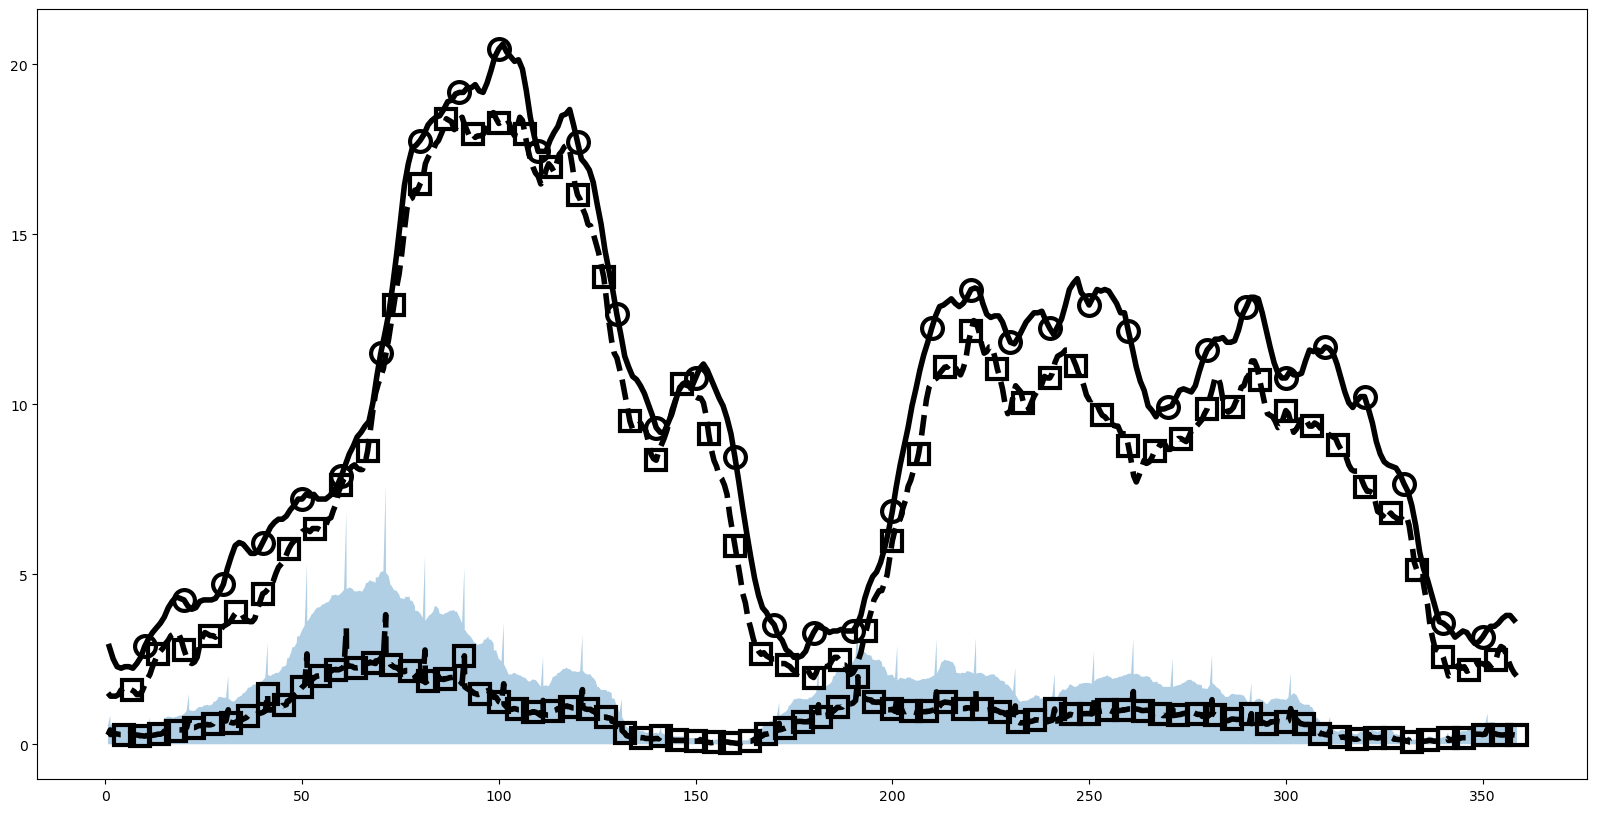

In [39]:
block_figs.block_plot_1d(block_meta,ensemble_block_1d,block_season,fig_out=True,dir_fig=fout_dir)



##### Plot 2D blocking: Ensemble ave, 1 ensemble member, or all ensemble members 


In [ ]:
block_figs.block_plot_2d(block_meta,ensemble_block_2d,block_season,fig_out=True,dir_fig=fout_dir,ens_plot='av')

In [ ]:
block_figs.block_plot_1d(block_meta,ensemble_block_1d,block_season,fig_out=True,dir_fig=fout_dir)